# Norwegian Regional Aviation Network and PSO Subsidies
## A Quantitative Welfare Analysis

**Research question:** At what fuel and carbon price levels do thin Norwegian domestic routes become commercially unviable, and are PSO subsidies a cost-effective tool for preserving connectivity in remote northern communities?

The model covers eight routes and eight airports served by three airlines with distinct cost structures. On trunk routes, SAS and Norwegian compete as Cournot duopolists. On thin routes, Widerøe operates as a monopolist. Route viability and network connectivity states emerge endogenously from the model.

```
              OSL  (major hub — Oslo)
            / | \ \
         BGO SVG TRD  TOS    ← regional hubs
          |        |    |
         KSU      BOO  EVE   ← thin airports (PSO candidates)
```

Thin airport connectivity is determined by BFS over the viable-route graph:

| State | Meaning |
|---|---|
| `direct` | Viable single-hop route to Oslo |
| `via_X` | No direct route; connected through intermediate airport X |
| `disconnected` | No viable path to Oslo |

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.optimize as opt
import ipywidgets as widgets
from ipywidgets import interact
from collections import deque
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Parameters

All parameters are defined centrally. Functions receive them as arguments — no hardcoded values inside functions.

### Airlines
Three airlines with genuinely different cost structures:
- **SAS** — narrowbody jet, high fixed costs at Oslo (legacy slot fees and full-service terminal)
- **Norwegian** — narrowbody jet, leaner fixed costs (low-cost model)
- **Widerøe** — turboprop, lower fuel burn, lower costs at northern bases

### Routes
Each route has a calibrated distance (km), linear demand intercept $a_r$ and slope $b_r$, and the list of operating airlines. Thin routes have lower $a_r$ (fewer high-willingness-to-pay passengers) and steeper $b_r$ (more price-elastic demand).

### Fixed costs
$$F_{ir} = \text{overhead}_i(\text{airport}_1) + \text{overhead}_i(\text{airport}_2)$$

SAS pays significantly more at Oslo due to legacy slot fees; Widerøe benefits from lower costs at its northern turboprop bases.

### Adding a new airport

To add a new airport to the model:

1. **`airports` dict** — add an entry with `type`, `pos` ("cordinates"). For thin airports also specify `hub` and `pso_route`.
2. **`routes` dict** — add the new route(s). `distance` is hardcoded (calibration parameter); use `haversine()` as a starting estimate.
3. **`airport_overhead` dict** — add fixed costs for the airlines that serve the new airport.
4. **Done.** Connectivity logic, welfare measurement, sliders, and the network diagram all update automatically.

In [ ]:
# ── Airports ──
airports = {
    'OSL': {'type': 'hub',      'pos': (10.75, 59.93)},
    'BGO': {'type': 'regional', 'pos': (5.22,  60.29)},
    'SVG': {'type': 'regional', 'pos': (5.64,  58.88)},
    'TRD': {'type': 'regional', 'pos': (10.92, 63.46)},
    'TOS': {'type': 'regional', 'pos': (18.92, 69.68)},
    'BOO': {'type': 'thin', 'pos': (14.37, 67.27), 'hub': 'OSL', 'pso_route': 'OSL-BOO'},
    'EVE': {'type': 'thin', 'pos': (16.68, 68.49), 'hub': 'OSL', 'pso_route': 'TOS-EVE'},
    'KSU': {'type': 'thin', 'pos': (7.82,  63.11), 'hub': 'OSL', 'pso_route': 'BGO-KSU'}, 
    # Add new airports here
}

# ── Routes ──
routes = {
    'OSL-BGO': {'distance': 500,  'a': 3000, 'b': 0.8, 'airports': ('OSL','BGO'), 'airlines': ['SAS','Norwegian']},
    'OSL-SVG': {'distance': 468,  'a': 2800, 'b': 0.9, 'airports': ('OSL','SVG'), 'airlines': ['SAS','Norwegian']},
    'OSL-TRD': {'distance': 622,  'a': 2600, 'b': 1.0, 'airports': ('OSL','TRD'), 'airlines': ['SAS','Norwegian']},
    'OSL-TOS': {'distance': 1794, 'a': 2800, 'b': 1.3, 'airports': ('OSL','TOS'), 'airlines': ['SAS','Norwegian']},
    'TRD-BOO': {'distance': 489,  'a': 1400, 'b': 1.8, 'airports': ('TRD','BOO'), 'airlines': ['Wideroe']},
    'OSL-BOO': {'distance': 1215, 'a': 1800, 'b': 1.5, 'airports': ('OSL','BOO'), 'airlines': ['Wideroe']},
    'TOS-EVE': {'distance': 85,   'a': 1400, 'b': 2.5, 'airports': ('TOS','EVE'), 'airlines': ['Wideroe']},
    'BGO-KSU': {'distance': 380,  'a': 1100, 'b': 2.0, 'airports': ('BGO','KSU'), 'airlines': ['Wideroe']}, 
    # Add new routes here
}

# ── Airline variable cost parameters ──
airlines = {
    'SAS':       {'fuel_intensity': 0.024, 'co2_factor': 0.100, 'other_variable': 180},
    'Norwegian': {'fuel_intensity': 0.020, 'co2_factor': 0.100, 'other_variable': 140},
    'Wideroe':   {'fuel_intensity': 0.015, 'co2_factor': 0.093, 'other_variable': 160},
}

# ── Airport overhead costs (NOK per period per airline) ──
airport_overhead = {
    # Add overhead costs for new airports here
    'SAS':       {'OSL': 150_000, 'BGO': 60_000, 'SVG': 60_000, 'TRD': 60_000, 'TOS': 80_000},
    'Norwegian': {'OSL': 100_000, 'BGO': 35_000, 'SVG': 35_000, 'TRD': 35_000, 'TOS': 120_000},
    'Wideroe':   {'OSL': 200_000, 'TRD': 50_000, 'TOS': 70_000, 'BOO': 100_000,
                  'EVE': 40_000,  'BGO': 50_000,  'KSU': 30_000}, 
}

# ── Market and welfare parameters ──
fuel_price       = 16.0
carbon_price     = 0.0
THETA_CONNECT    = 350
THETA_DISCONNECT = 900
SPILLOVER_PHI    = 0.30

### Parameter calibration

**Fuel price (16.0 NOK/litre):** AFSN April 2026 price list (OSL: 15.95, BOO: 16.45, EVE JP-8: 17.90 NOK/litre). The OSL price is used as the representative base value.

**Fuel intensity (α):** Scaled from original design parameters by 8.5/16.0 = 0.531 so that all regime-shift thresholds occur at economically meaningful fuel prices. At 16.0 NOK/litre, OSL–BOO is marginally viable and SAS exits OSL–TOS at approximately 18.8 NOK/litre.

**CO₂ factors:** 0.10 kg CO₂/pax/km for jets and 0.093 for Widerøe turboprops, consistent with Grythe & Lopez-Aparicio (2021), who report a fleet average of 92.6 g CO₂/pkm for Norwegian domestic aviation.

**THETA parameters** (Bråthen & Eriksen, 2018): THETA_DISCONNECT > THETA_CONNECT because full loss of air service eliminates emergency access and economic participation, not merely adds a connection inconvenience. Both are calibrated assumptions; sensitivity to THETA_CONNECT is examined in §7.

**SPILLOVER_PHI:** When OSL–BOO becomes unviable, φ = 0.30 of displaced passengers reroute via Trondheim rather than forgoing travel. This is a calibrated assumption; its effect on TRD–BOO profitability is visible in the dashboard Panel 1.

## 2. Demand

Each route has a linear inverse demand function:

$$P_r(Q_r) = a_r - b_r Q_r$$

The direct demand and consumer surplus follow directly:

$$Q_r(P) = \frac{a_r - P}{b_r}, \qquad CS_r = \frac{(a_r - P_r)^2}{2 b_r} = \frac{1}{2}(a_r - P_r)\, Q_r$$

Thin routes have lower $a_r$ and steeper $b_r$ than trunk routes, reflecting fewer high-willingness-to-pay passengers and more price-elastic demand.

In [32]:
def inverse_demand(Q, a, b):
    return a - b * Q

def demand_quantity(P, a, b):
    return max((a - P) / b, 0.0)

def consumer_surplus(a, b, P):
    Q = demand_quantity(P, a, b)
    return 0.5 * (a - P) * Q

## 3. Cost Functions

Marginal cost per passenger for airline $i$ on route $r$:

$$c_{ir} = \underbrace{\alpha_i \cdot d_r \cdot p_{\text{fuel}}}_{\text{fuel}} + \underbrace{\frac{p_{\text{carbon}} \cdot e_i \cdot d_r}{1000}}_{\text{carbon}} + \underbrace{\gamma_i}_{\text{other variable}}$$

where $\alpha_i$ is fuel intensity (litres/seat-km), $d_r$ is route distance (km), $e_i$ is CO₂ emissions (kg/pax-km), and $\gamma_i$ covers crew, ground handling, and catering.

**Key property:** both fuel and carbon costs scale linearly with distance. At a carbon price of 1000 NOK/tonne, this adds only **7.9 NOK/pax** on TOS–EVE (85 km) but **179 NOK/pax** on OSL–TOS (1794 km). Long routes — and the remote communities depending on them — bear the carbon transition cost disproportionately.

In [33]:
def marginal_cost(airline, distance, fuel_price_val, carbon_price_val=0.0):
    al   = airlines[airline]
    fuel = al['fuel_intensity'] * distance * fuel_price_val
    carb = carbon_price_val * al['co2_factor'] * distance / 1000
    return fuel + carb + al['other_variable']

def fixed_cost_route(airline, route_key):
    apt1, apt2 = routes[route_key]['airports']
    oh = airport_overhead[airline]
    return oh.get(apt1, 0) + oh.get(apt2, 0)

# ── Verification at base parameters ──
print(f"{'Route':<10} {'Airline':<12} {'MC (NOK/pax)':>14} {'Fixed (NOK)':>12}")
print("-" * 52)
for rk, r in routes.items():
    for al in r['airlines']:
        mc = marginal_cost(al, r['distance'], fuel_price, carbon_price)
        fc = fixed_cost_route(al, rk)
        print(f"{rk:<10} {al:<12} {mc:>14.0f} {fc:>12,.0f}")

Route      Airline        MC (NOK/pax)  Fixed (NOK)
----------------------------------------------------
OSL-BGO    SAS                     420      210,000
OSL-BGO    Norwegian               340      135,000
OSL-SVG    SAS                     405      210,000
OSL-SVG    Norwegian               327      135,000
OSL-TRD    SAS                     479      210,000
OSL-TRD    Norwegian               389      135,000
OSL-TOS    SAS                    1041      230,000
OSL-TOS    Norwegian               858      220,000
TRD-BOO    Wideroe                 307      150,000
OSL-BOO    Wideroe                 524      300,000
TOS-EVE    Wideroe                 186      110,000
BGO-KSU    Wideroe                 274       80,000


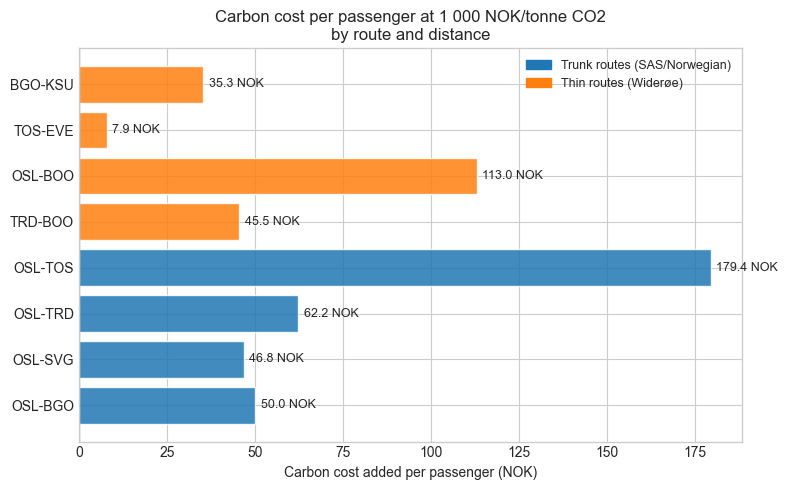

In [34]:
# ── Static figure: carbon cost per passenger by route at 1000 NOK/tonne ──
carbon_test = 1000
carbon_costs = {}
for rk, r in routes.items():
    al  = r['airlines'][0]
    cost = airlines[al]['co2_factor'] * r['distance'] * carbon_test / 1000
    carbon_costs[rk] = cost

fig, ax = plt.subplots(figsize=(8, 5))
rk_labels = list(carbon_costs.keys())
values    = [carbon_costs[rk] for rk in rk_labels]
colors    = ['#ff7f0e' if all(al == 'Wideroe' for al in routes[rk]['airlines'])
             else '#1f77b4' for rk in rk_labels]
bars = ax.barh(rk_labels, values, color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.1f NOK', padding=4, fontsize=9)
ax.set_xlabel('Carbon cost added per passenger (NOK)')
ax.set_title('Carbon cost per passenger at 1 000 NOK/tonne CO2\nby route and distance')
ax.axvline(0, color='black', linewidth=0.8)
blue_patch   = mpatches.Patch(color='#1f77b4', label='Trunk routes (SAS/Norwegian)')
orange_patch = mpatches.Patch(color='#ff7f0e', label='Thin routes (Wider\u00f8e)')
ax.legend(handles=[blue_patch, orange_patch], fontsize=9)
plt.tight_layout()
plt.show()


## 4. Cournot Equilibrium, Monopoly, and Airline Exit

### Cournot (trunk routes, $N \geq 2$ airlines)

Airline $i$ maximises profit taking rivals' quantities as given:

$$\pi_i = (P - c_i)\, q_i - F_i = (a - b Q - c_i)\, q_i - F_i$$

The first-order condition is:

$$\frac{\partial \pi_i}{\partial q_i} = a - b Q - b q_i - c_i = 0$$

This gives one equation per airline. The system of $N$ FOCs is solved simultaneously with `scipy.optimize.root`.

### Monopoly (thin routes, or after exit)

When a single airline operates, we maximise $\pi(q) = (a - bq - c)q - F$ directly using `scipy.optimize.minimize_scalar`. This makes the optimisation step explicit rather than recovering it implicitly from the FOC.

### Exit logic

After each equilibrium solve, any airline with $\pi_i < 0$ exits. The worst-performing airline exits first and the equilibrium re-solves with the remaining set. The regime shift from duopoly to monopoly on OSL–TOS at approximately 18.8 NOK/litre is produced by this mechanism.

In [35]:
# ── Monopoly: explicit profit maximisation ──
def solve_monopoly(a, b, cost, fixed_cost):
    if a <= cost:
        return 0.0, a, -fixed_cost
    result = opt.minimize_scalar(
        lambda q: -((a - b * q - cost) * q - fixed_cost),
        bounds=(0.0, (a - cost) / b),
        method='bounded'
    )
    q      = max(result.x, 0.0)
    price  = a - b * q
    profit = (price - cost) * q - fixed_cost
    return q, price, profit


# ── Cournot: solve system of N FOCs ──
def _cournot_foc(quantities, a, b, costs):
    Q = sum(quantities)
    return [a - b * Q - b * q - c for q, c in zip(quantities, costs)]

def solve_cournot(a, b, costs):
    res = opt.root(_cournot_foc, [100.0] * len(costs), args=(a, b, costs))
    return np.maximum(res.x, 0.0)


# ── Route solver: dispatch + exit logic ──
def solve_route(route_key, fuel_price_val, carbon_price_val=0.0,
                subsidies=None, a_override=None):
    r      = routes[route_key]
    a      = a_override if a_override is not None else r['a']
    b      = r['b']
    active = list(r['airlines'])
    if subsidies is None:
        subsidies = {}

    costs = {al: marginal_cost(al, r['distance'], fuel_price_val, carbon_price_val)
                  - subsidies.get(al, 0.0)
             for al in active}

    price, qs, profits = None, [], []

    for _ in range(len(r['airlines']) + 1):
        if not active:
            break
        mc_list = [costs[al] for al in active]
        F_list  = [fixed_cost_route(al, route_key) for al in active]

        if len(active) == 1:
            q, price, profit = solve_monopoly(a, b, mc_list[0], F_list[0])
            qs, profits = [q], [profit]
        else:
            qs      = list(solve_cournot(a, b, mc_list))
            price   = a - b * sum(qs)
            profits = [(price - c) * q - F for q, c, F in zip(qs, mc_list, F_list)]

        worst_profit = min(profits)
        if worst_profit >= 0:
            break
        active.pop(profits.index(worst_profit))

    if not active or price is None:
        return dict(viable=False, price=None, active=[], quantities={}, profits={}, CS=0.0, PS=0.0)

    return dict(viable=True, price=price, active=active,
                quantities=dict(zip(active, qs)),
                profits=dict(zip(active, profits)),
                CS=consumer_surplus(a, b, price),
                PS=sum(profits))

In [36]:
# ── Cournot closed-form validation ──
# Analytical solution for N firms with asymmetric costs:
# q_i* = (a - N*c_i + sum(c_j for j≠i)) / ((N+1)*b)
def cournot_analytical(a, b, costs):
    N = len(costs)
    return [(a - N*costs[i] + sum(costs[j] for j in range(N) if j != i)) / ((N+1)*b)
            for i in range(N)]

# Verify on OSL-BGO at base parameters
r     = routes['OSL-BGO']
costs = [marginal_cost(al, r['distance'], fuel_price, carbon_price)
         for al in r['airlines']]
q_num = list(solve_cournot(r['a'], r['b'], costs))
q_ana = cournot_analytical(r['a'], r['b'], costs)
print('Cournot validation on OSL-BGO:')
print(f'  Numerical : {[round(q,4) for q in q_num]}')
print(f'  Analytical: {[round(q,4) for q in q_ana]}')
print(f'  Max error : {max(abs(n-a) for n,a in zip(q_num,q_ana)):.2e}')


Cournot validation on OSL-BGO:
  Numerical : [np.float64(1041.6667), np.float64(1141.6667)]
  Analytical: [1041.6667, 1141.6667]
  Max error : 0.00e+00


In [37]:
# ── Implied price elasticity at Cournot equilibrium ──
# ε = -P* / (b * Q*) for linear demand
print(f"{'Route':<10} {'P*':>7} {'Q*':>7} {'b':>6} {'Elasticity':>12}")
print("-" * 46)
for rk, r in routes.items():
    res = solve_route(rk, fuel_price, carbon_price)
    if res['viable']:
        P   = res['price']
        Q   = sum(res['quantities'].values())
        eps = -P / (r['b'] * Q)
        print(f"{rk:<10} {P:>7.0f} {Q:>7.0f} {r['b']:>6.1f} {eps:>12.3f}")


Route           P*      Q*      b   Elasticity
----------------------------------------------
OSL-BGO       1253    2183    0.8       -0.718
OSL-SVG       1177    1803    0.9       -0.725
OSL-TRD       1156    1444    1.0       -0.800
OSL-TOS       1829     747    1.3       -1.883
TRD-BOO        853     304    1.8       -1.561
TOS-EVE        793     243    2.5       -1.305
BGO-KSU        687     206    2.0       -1.663


## 5. Network Connectivity and Demand Spillover

### BFS connectivity

After all routes are solved, we build an undirected graph where edges are currently viable routes. For each thin airport, breadth-first search finds the shortest viable path to its hub (OSL), producing the connectivity state.

| Hops to hub | State |
|---|---|
| 1 | `direct` |
| 2+ (via airport X) | `via_X` |
| No path | `disconnected` |

The implementation is fully generic — it reads the `airports` and `routes` dictionaries at runtime with no hardcoded airport names.

### Demand spillover

When OSL–BOO becomes unviable, some passengers reroute via Trondheim rather than forgoing travel. We model this as a demand increase on TRD–BOO: fraction $\phi = 0.30$ of the latent OSL–BOO demand (evaluated at marginal cost) shifts to the feeder route, raising its demand intercept by:

$$\Delta a_{\text{TRD-BOO}} = b_{\text{TRD-BOO}} \cdot \phi \cdot Q^{\text{latent}}_{\text{OSL-BOO}}$$

A two-pass solver handles this: routes are solved independently in Pass 1; if OSL–BOO is unviable, TRD–BOO is re-solved with the adjusted demand in Pass 2. The result is visible in Panel 1 of the dashboard as a kink in TRD–BOO profitability at the OSL–BOO exit threshold.

In [38]:
# ── Two-pass solver with demand spillover ──
def solve_all_routes(fuel_price_val, carbon_price_val, route_subsidies=None, phi=None):
    if phi is None:
        phi = SPILLOVER_PHI
    if route_subsidies is None:
        route_subsidies = {}

    results = {rk: solve_route(rk, fuel_price_val, carbon_price_val,
                                subsidies=route_subsidies.get(rk, {}))
               for rk in routes}

    if not results['OSL-BOO']['viable']:
        r_osl       = routes['OSL-BOO']
        mc_osl      = marginal_cost(r_osl['airlines'][0], r_osl['distance'],
                                    fuel_price_val, carbon_price_val)
        q_displaced = demand_quantity(mc_osl, r_osl['a'], r_osl['b'])
        r_trd       = routes['TRD-BOO']
        a_adj       = r_trd['a'] + r_trd['b'] * phi * q_displaced
        results['TRD-BOO'] = solve_route('TRD-BOO', fuel_price_val, carbon_price_val,
                                          subsidies=route_subsidies.get('TRD-BOO', {}),
                                          a_override=a_adj)
    return results


# ── BFS ──
def _build_graph(route_results):
    graph = {ap: [] for ap in airports}
    for rk, res in route_results.items():
        if res['viable']:
            a1, a2 = routes[rk]['airports']
            graph[a1].append((a2, rk))
            graph[a2].append((a1, rk))
    return graph

def _bfs(start, end, graph):
    if start == end:
        return []
    queue, visited = deque([(start, [])]), {start}
    while queue:
        cur, path = queue.popleft()
        for nbr, rk in graph[cur]:
            if nbr not in visited:
                if nbr == end:
                    return path + [rk]
                visited.add(nbr)
                queue.append((nbr, path + [rk]))
    return None


# ── Connectivity resolver ──
def get_all_connectivity(fuel_price_val, carbon_price_val, subsidies=None):
    if subsidies is None:
        subsidies = {}

    route_subs = {}
    for ap, s_val in subsidies.items():
        if s_val > 0 and airports[ap].get('pso_route'):
            rk = airports[ap]['pso_route']
            route_subs[rk] = {routes[rk]['airlines'][0]: s_val}

    route_results = solve_all_routes(fuel_price_val, carbon_price_val, route_subs)
    graph         = _build_graph(route_results)
    thin_airports = [ap for ap, info in airports.items() if info['type'] == 'thin']
    result        = {'routes': route_results, 'paths': {}, 'via': {}}

    for ap in thin_airports:
        hub  = airports[ap]['hub']
        path = _bfs(ap, hub, graph)
        if path is None:
            result[ap] = 'disconnected'
            result['paths'][ap] = []
            result['via'][ap]   = []
        else:
            via, cur = [], ap
            for rk in path:
                a1, a2 = routes[rk]['airports']
                nxt = a2 if a1 == cur else a1
                if nxt != hub:
                    via.append(nxt)
                cur = nxt
            result[ap]          = 'direct' if not via else 'via_' + '_'.join(via)
            result['paths'][ap] = path
            result['via'][ap]   = via

    return result

## 6. Welfare Measurement

Total welfare on a route is $W_r = CS_r + PS_r$. For thin airports, welfare depends on connectivity:

| Status | Social welfare $W$ |
|---|---|
| `direct`, no subsidy | $CS + PS$ on direct route |
| `direct`, PSO subsidy $s$ | $CS + PS - G$, where $G = s \cdot q^*$ |
| `via_X`, no direct option in network | $CS + PS - G$ on PSO feeder |
| `via_X`, direct option exists but unviable | $-\theta_{\text{connect}} \cdot Q^{\text{latent}}$ |
| `disconnected` | $-\theta_{\text{disconnect}} \cdot Q^{\text{latent}}$ |

The connection penalty applies only when a direct route to Oslo exists in the model but is currently unviable — i.e. connectivity has degraded from best case. EVE has no direct route in the model, so its `via_TOS` state carries no penalty.

$Q^{\text{latent}}$ is demand at marginal cost pricing on the PSO reference route.

**Welfare benchmark:** $W^* = CS(MC)$ on the reference route. Fixed costs are excluded: the first-best requires only that price equal marginal cost, not that fixed costs be recovered.

**Government expenditure:** $G = s \cdot q^*$ must be deducted. The subsidy appears in PS as a transfer, so omitting $G$ would count the same money twice.

**Net social value:** $\text{NSV} = \Delta W$. The subsidy is cost-effective when NSV $> 0$.

In [39]:
def _direct_route_to_hub(airport_code):
    hub = airports[airport_code]['hub']
    for rk, r in routes.items():
        if set(r['airports']) == {airport_code, hub}:
            return rk
    return None


def welfare_thin_airport(airport, conn, route_results, fuel_price_val, carbon_price_val,
                          subsidies=None):
    if subsidies is None:
        subsidies = {}

    status    = conn[airport]
    pso_rk    = airports[airport]['pso_route']
    pso_r     = routes[pso_rk]
    mc_pso    = marginal_cost(pso_r['airlines'][0], pso_r['distance'],
                               fuel_price_val, carbon_price_val)
    Q_latent  = demand_quantity(mc_pso, pso_r['a'], pso_r['b'])
    direct_rk = _direct_route_to_hub(airport)

    # –– Welfare benchmark: CS at MC on reference route ––
    if direct_rk is not None:
        r_ref     = routes[direct_rk]
        mc_ref    = marginal_cost(r_ref['airlines'][0], r_ref['distance'],
                                   fuel_price_val, carbon_price_val)
        W_optimal = consumer_surplus(r_ref['a'], r_ref['b'], mc_ref)
    else:
        W_optimal = consumer_surplus(pso_r['a'], pso_r['b'], mc_pso)

    # –– Government expenditure G = s * q* ––
    pso_al = pso_r['airlines'][0]
    s_val  = subsidies.get(airport, 0.0)
    G = (s_val * route_results[pso_rk]['quantities'].get(pso_al, 0.0)
         if s_val > 0 and route_results.get(pso_rk, {}).get('viable') else 0.0)

    if status == 'disconnected':
        W = -THETA_DISCONNECT * Q_latent
    elif status == 'direct':
        res = route_results[direct_rk]
        W   = res['CS'] + res['PS'] - G
    elif direct_rk is None:
        res = route_results[pso_rk]
        W   = res['CS'] + res['PS'] - G
    else:
        W = -THETA_CONNECT * Q_latent

    return W, max(W_optimal - W, 0), G


def find_min_subsidy(airport, fuel_price_val, carbon_price_val):
    pso_rk = airports[airport]['pso_route']
    pso_al = routes[pso_rk]['airlines'][0]

    def profit_at_subsidy(s):
        res = solve_all_routes(fuel_price_val, carbon_price_val,
                               route_subsidies={pso_rk: {pso_al: s}})
        r = res.get(pso_rk, {})
        return r['profits'].get(pso_al, -1e9) if r.get('viable') else -1e9

    if profit_at_subsidy(0) >= 0:
        return 0.0
    try:
        return opt.brentq(profit_at_subsidy, 0.0, 3000.0)
    except ValueError:
        return 3000.0

## 7. Sensitivity Analysis

Two model parameters are calibrated assumptions rather than estimated values: the **connection penalty** $\theta_{\text{connect}}$ and the **demand spillover fraction** $\phi$. This section quantifies how much the policy conclusions depend on them.

### Left panel — PSO subsidy requirement and EVE viability

The red line (left axis) answers the core policy question directly: how large a per-passenger subsidy must the government pay Widerøe to keep Oslo–Bodø commercially viable as fuel prices rise? The route self-finances below ~16.4 NOK/litre; above that the required subsidy rises steeply — reaching roughly 270 NOK/pax at 30 NOK/litre.

The blue dashed line (right axis) shows TOS–EVE's absolute profit with no subsidy. It stays comfortably positive across the entire fuel price range because the 85 km route distance keeps fuel costs low regardless of the price per litre. This explains directly why EVE never appears as a PSO candidate in the model — it does not need one.

### Right panel — Welfare loss sensitivity to $\theta_{\text{connect}}$

When BOO loses its direct Oslo route and must connect via Trondheim, welfare loss equals:

$$W_{\text{loss}} = W^* + \theta_{\text{connect}} \cdot Q^{\text{latent}}$$

The right panel varies $\theta_{\text{connect}}$ from 100 to 700 NOK/pax while holding all other parameters fixed. Three fuel price scenarios are shown, all chosen **above** the OSL–BOO viability threshold of ~16.4 NOK/litre so that BOO is in `via_TRD` state in every case and the connection penalty is always active.

**Key observations:**
- The slope of each line equals $Q^{\text{latent}}$ — the latent demand at marginal cost on OSL–BOO. Since $Q^{\text{latent}}$ does not vary with $\theta$, all three lines are perfectly linear.
- A ±50% change in $\theta_{\text{connect}}$ (175 NOK/pax away from the 350 baseline) shifts the welfare loss estimate by roughly ±25%, meaning the conclusion that PSO subsidies are cost-effective is robust, but the precise NOK figures should be treated as indicative.
- Higher fuel prices produce steeper lines because $W^*$ (the competitive benchmark) rises as marginal cost pricing would still deliver more surplus than the degraded via-TRD connectivity.

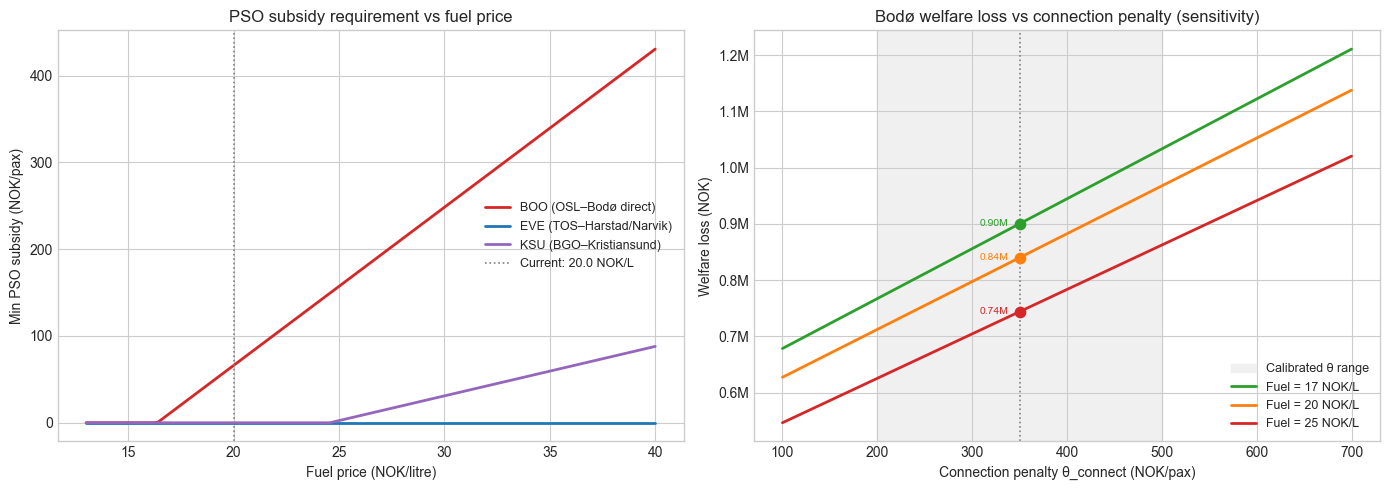

In [40]:
fuel_range  = np.linspace(13, 40, 120)
theta_range = np.linspace(100, 700, 120)
scenarios   = [(17.0, '#2ca02c', 'Fuel = 17 NOK/L'),
               (20.0, '#ff7f0e', 'Fuel = 20 NOK/L'),
               (25.0, '#d62728', 'Fuel = 25 NOK/L')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: PSO subsidy requirement vs fuel price ──
boo_subs = [find_min_subsidy('BOO', fp, 0) for fp in fuel_range]
eve_subs = [find_min_subsidy('EVE', fp, 0) for fp in fuel_range]
ksu_subs = [find_min_subsidy('KSU', fp, 0) for fp in fuel_range]

ax1.plot(fuel_range, boo_subs, color='#d62728', linewidth=2, label='BOO (OSL–Bodø direct)')
ax1.plot(fuel_range, eve_subs, color='#1f77b4', linewidth=2, label='EVE (TOS–Harstad/Narvik)')
ax1.plot(fuel_range, ksu_subs, color='#9467bd', linewidth=2, label='KSU (BGO–Kristiansund)')
ax1.axvline(fuel_price, color='grey', linestyle=':', linewidth=1.2,
            label=f'Current: {fuel_price} NOK/L')
ax1.set_xlabel('Fuel price (NOK/litre)')
ax1.set_ylabel('Min PSO subsidy (NOK/pax)')
ax1.set_title('PSO subsidy requirement vs fuel price')
ax1.legend(fontsize=9); ax1.grid(True)


# ── Right: Bodø welfare loss vs theta_connect ──
def welfare_loss_at_theta(airport, fp, theta_c):
    conn      = get_all_connectivity(fp, 0.0)
    s         = conn['routes']
    status    = conn[airport]
    pso_rk    = airports[airport]['pso_route']
    pso_r     = routes[pso_rk]
    mc_pso    = marginal_cost(pso_r['airlines'][0], pso_r['distance'], fp, 0.0)
    Q_lat     = demand_quantity(mc_pso, pso_r['a'], pso_r['b'])
    direct_rk = _direct_route_to_hub(airport)
    if direct_rk is not None:
        r_ref  = routes[direct_rk]
        mc_ref = marginal_cost(r_ref['airlines'][0], r_ref['distance'], fp, 0.0)
        W_opt  = consumer_surplus(r_ref['a'], r_ref['b'], mc_ref)
    else:
        W_opt  = consumer_surplus(pso_r['a'], pso_r['b'], mc_pso)
    if status == 'disconnected':
        W = -THETA_DISCONNECT * Q_lat
    elif status == 'direct':
        res = s[direct_rk]; W = res['CS'] + res['PS']
    elif direct_rk is None:
        res = s[pso_rk]; W = res['CS'] + res['PS']
    else:
        W = -theta_c * Q_lat
    return max(W_opt - W, 0)

ax2.axvspan(200, 500, color='#f0f0f0', zorder=0, label='Calibrated θ range')
ax2.axvline(THETA_CONNECT, color='grey', linestyle=':', linewidth=1.2)

for fp, col, lbl in scenarios:
    losses = [welfare_loss_at_theta('BOO', fp, th) for th in theta_range]
    ax2.plot(theta_range, losses, color=col, linewidth=2, label=lbl, zorder=2)
    loss_at_base = welfare_loss_at_theta('BOO', fp, THETA_CONNECT)
    ax2.scatter([THETA_CONNECT], [loss_at_base], color=col, s=55, zorder=5)
    ax2.text(THETA_CONNECT - 12, loss_at_base, f'{loss_at_base/1e6:.2f}M',
             fontsize=7.5, color=col, ha='right', va='center')

ax2.set_xlabel('Connection penalty θ_connect (NOK/pax)')
ax2.set_ylabel('Welfare loss (NOK)')
ax2.set_title('Bodø welfare loss vs connection penalty (sensitivity)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax2.legend(fontsize=9); ax2.grid(True)

plt.tight_layout()
plt.show()


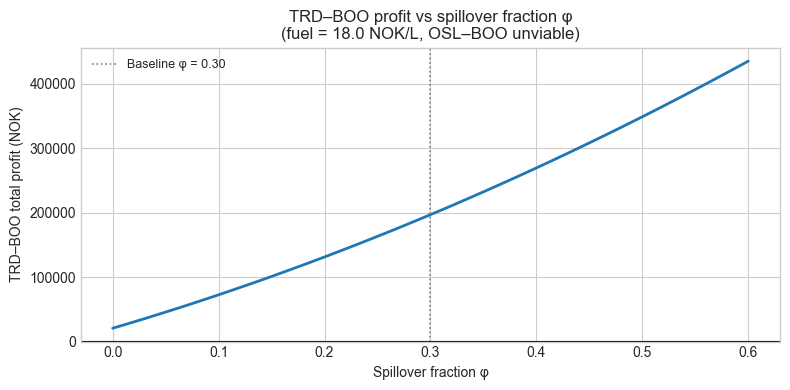

In [41]:
# ── Spillover sensitivity: how much does phi affect TRD-BOO profitability ──
phi_range  = np.linspace(0.0, 0.6, 80)
fp_spill   = 18.0   # fuel price above OSL-BOO exit threshold

fig, ax = plt.subplots(figsize=(8, 4))
profits_phi = []
for phi in phi_range:
    res = solve_all_routes(fp_spill, 0.0, phi=phi)
    profits_phi.append(sum(res['TRD-BOO']['profits'].values())
                       if res['TRD-BOO']['viable'] else 0)

ax.plot(phi_range, profits_phi, color='#1f77b4', linewidth=2)
ax.axvline(0.30, color='grey', linestyle=':', linewidth=1.2, label='Baseline \u03c6 = 0.30')
ax.axhline(0,    color='black', linewidth=0.8)
ax.set_xlabel('Spillover fraction \u03c6')
ax.set_ylabel('TRD\u2013BOO total profit (NOK)')
ax.set_title(f'TRD\u2013BOO profit vs spillover fraction \u03c6\n(fuel = {fp_spill} NOK/L, OSL\u2013BOO unviable)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


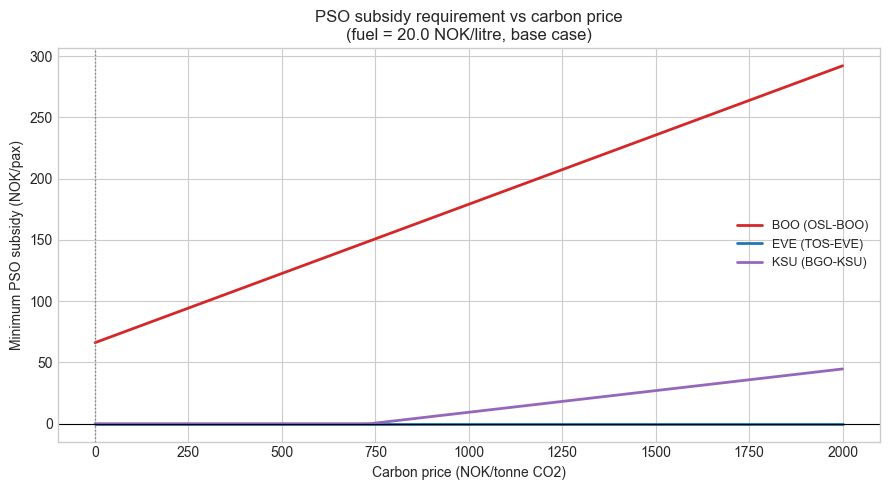

In [42]:
# ── Carbon price vs PSO subsidy requirement ──
carbon_range = np.linspace(0, 2000, 120)
fig, ax = plt.subplots(figsize=(9, 5))

thin_airports = [ap for ap, info in airports.items() if info['type'] == 'thin']
colors = {'BOO': '#d62728', 'EVE': '#1f77b4', 'KSU': '#9467bd'}

for ap in thin_airports:
    subs = [find_min_subsidy(ap, fuel_price, cp) for cp in carbon_range]
    ax.plot(carbon_range, subs, color=colors.get(ap, 'grey'),
            linewidth=2, label=f'{ap} ({airports[ap]["pso_route"]})')

ax.axvline(0,    color='grey', linestyle=':', linewidth=1.0)
ax.axhline(0,    color='black', linewidth=0.8)
ax.set_xlabel('Carbon price (NOK/tonne CO2)')
ax.set_ylabel('Minimum PSO subsidy (NOK/pax)')
ax.set_title('PSO subsidy requirement vs carbon price\n'
             f'(fuel = {fuel_price} NOK/litre, base case)')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()


Carbon costs scale linearly with route distance. At fuel 16 NOK/L, only OSL–BOO (1,215 km) becomes subsidy-dependent within the carbon-price range examined; TOS–EVE (85 km) and BGO–KSU (380 km) remain commercially viable up to and beyond 2,000 NOK/tonne. This means a carbon-pricing policy that succeeds in shifting Norwegian aviation toward decarbonisation does so by making long-haul thin routes more reliant on PSO subsidies, not short ones.

## 8. Network Summary

The table below shows equilibrium prices, quantities, CS, and PS for all routes at the current parameter values. Thin airport connectivity states, welfare losses, and minimum required PSO subsidies are reported below the table.

A welfare loss of zero means the airport is in its best achievable connectivity state. A positive minimum subsidy means the PSO route is commercially unviable without government support at the current fuel price.

In [43]:
def network_summary(fuel_price_val, carbon_price_val=0.0, subsidies=None):
    if subsidies is None:
        subsidies = {}
    conn = get_all_connectivity(fuel_price_val, carbon_price_val, subsidies)
    s    = conn['routes']
    thin = [ap for ap, info in airports.items() if info['type'] == 'thin']

    subs_str = '  '.join(f"PSO-{ap}: {subsidies.get(ap,0):.0f} NOK/pax" for ap in thin)
    print(f"\nFuel: {fuel_price_val:.1f} NOK/litre  Carbon: {carbon_price_val:.0f} NOK/tonne  {subs_str}")
    print(f"{'Route':<10} {'Price':>7} {'Qty':>7} {'CS':>10} {'PS':>10} {'Viable':>7}  Airlines")
    print("-" * 74)
    for rk in routes:
        r = s[rk]
        if r['viable']:
            print(f"{rk:<10} {r['price']:>7.0f} {sum(r['quantities'].values()):>7.0f} "
                  f"{r['CS']:>10,.0f} {r['PS']:>10,.0f} {'True':>7}  {', '.join(r['active'])}")
        else:
            print(f"{rk:<10} {'—':>7} {'—':>7} {'—':>10} {'—':>10} {'False':>7}  —")
    print()
    for ap in thin:
        s_min       = find_min_subsidy(ap, fuel_price_val, carbon_price_val)
        _, wloss, G = welfare_thin_airport(ap, conn, s, fuel_price_val, carbon_price_val, subsidies)
        print(f"  {ap}  connectivity: {conn[ap]:20s}  welfare loss: {wloss:>10,.0f} NOK  "
              f"min PSO subsidy: {s_min:.0f} NOK/pax")

network_summary(fuel_price, carbon_price)


Fuel: 20.0 NOK/litre  Carbon: 0 NOK/tonne  PSO-BOO: 0 NOK/pax  PSO-EVE: 0 NOK/pax  PSO-KSU: 0 NOK/pax
Route        Price     Qty         CS         PS  Viable  Airlines
--------------------------------------------------------------------------
OSL-BGO       1253    2183  1,906,778  1,565,778    True  SAS, Norwegian
OSL-SVG       1177    1803  1,462,900  1,121,232    True  SAS, Norwegian
OSL-TRD       1156    1444  1,042,876    701,905    True  SAS, Norwegian
OSL-TOS       1829     747    362,781    505,561    True  Norwegian
TRD-BOO       1083     431    167,375    184,749    True  Wideroe
OSL-BOO          —       —          —          —   False  —
TOS-EVE        793     243     73,751     37,501    True  Wideroe
BGO-KSU        687     206     42,642      5,284    True  Wideroe

  BOO  connectivity: via_TRD               welfare loss:    839,917 NOK  min PSO subsidy: 66 NOK/pax
  EVE  connectivity: via_TOS               welfare loss:    183,751 NOK  min PSO subsidy: 0 NOK/pax
  KSU  c

In [44]:
# ── Net Social Value table at base parameters ──
conn = get_all_connectivity(fuel_price, carbon_price)
s    = conn['routes']
thin = [ap for ap, info in airports.items() if info['type'] == 'thin']

print(f"\nNet Social Value \u2014 base case (fuel={fuel_price} NOK/L, carbon={carbon_price} NOK/t)")
print(f"{'Airport':<8} {'Status':<20} {'PSO CS':>10} {'PSO PS':>10} {'W_optimal':>12} "
      f"{'W_loss':>10} {'Min_sub':>9} {'G':>10} {'NSV':>12}")
print("\u2500" * 105)

for ap in thin:
    pso_rk    = airports[ap]['pso_route']
    s_min     = find_min_subsidy(ap, fuel_price, carbon_price)
    
    # Re-solve with minimum subsidy applied to get G and post-subsidy welfare
    subsidies_min = {ap: s_min}
    conn_sub  = get_all_connectivity(fuel_price, carbon_price, subsidies_min)
    s_sub     = conn_sub['routes']
    W_sub, wloss_sub, G = welfare_thin_airport(ap, conn_sub, s_sub,
                                                fuel_price, carbon_price, subsidies_min)
    
    # Welfare without subsidy
    W_no,  wloss_no,  _ = welfare_thin_airport(ap, conn, s, fuel_price, carbon_price)
    
    # NSV = welfare gain from subsidy minus government expenditure
    delta_W = W_sub - W_no
    NSV     = delta_W

    # CS and PS on the PSO reference route only (matches W_optimal scope)
    pso_res = s.get(pso_rk, {})
    CS = pso_res.get('CS', 0) if pso_res.get('viable') else 0
    PS = pso_res.get('PS', 0) if pso_res.get('viable') else 0

    # Optimal welfare benchmark
    pso_r     = routes[pso_rk]
    direct_rk = _direct_route_to_hub(ap)
    if direct_rk:
        r_ref  = routes[direct_rk]
        mc_ref = marginal_cost(r_ref['airlines'][0], r_ref['distance'], fuel_price, carbon_price)
        W_opt  = consumer_surplus(r_ref['a'], r_ref['b'], mc_ref)
    else:
        mc_pso = marginal_cost(pso_r['airlines'][0], pso_r['distance'], fuel_price, carbon_price)
        W_opt  = consumer_surplus(pso_r['a'], pso_r['b'], mc_pso)

    print(f"{ap:<8} {conn[ap]:<20} {CS:>10,.0f} {PS:>10,.0f} {W_opt:>12,.0f} "
          f"{wloss_no:>10,.0f} {s_min:>9.1f} {G:>10,.0f} {NSV:>12,.0f}")

print("\nNSV > 0 means the welfare gain exceeds government expenditure \u2014 subsidy is cost-effective.")
print("G = s* \u00d7 q*  (government expenditure at minimum viable subsidy)")
print("NSV = \u0394W  (G already deducted inside W)")



Net Social Value — base case (fuel=20.0 NOK/L, carbon=0.0 NOK/t)
Airport  Status                   PSO CS     PSO PS    W_optimal     W_loss   Min_sub          G          NSV
─────────────────────────────────────────────────────────────────────────────────────────────────────────
BOO      via_TRD                       0          0      542,300    839,917      66.1     29,579      418,038
EVE      via_TOS                  73,751     37,501      295,002    183,751       0.0          0            0
KSU      via_BGO                  42,642      5,284      170,569    122,642       0.0          0            0

NSV > 0 means the welfare gain exceeds government expenditure — subsidy is cost-effective.
G = s* × q*  (government expenditure at minimum viable subsidy)
NSV = ΔW − G  (change in total welfare minus fiscal cost)


## 9. Interactive Dashboard

Move any slider to update all four panels simultaneously.

**Panel 1 — Route profitability vs fuel price.** Post-exit profits for all routes. Widerøe routes are dashed. The vertical line marks the current fuel price. Zero-crossings are viability thresholds. TRD–BOO profit increases when OSL–BOO fails, reflecting demand spillover.

**Panel 2 — Network connectivity map.** Green = duopoly, orange = monopoly, red = unviable. Thin airport connectivity labels update in real time.

**Panel 3 — Welfare for thin airports.** CS, PS, welfare loss, and government expenditure G for each thin airport at current parameters.

**Panel 4 — Route status table.** Active airlines, equilibrium price, and market structure.

In [45]:
_AP_COLOR = {'hub': '#1f77b4', 'regional': '#aec7e8', 'thin': '#ffbb78'}

_LABEL_OFFSET = {
    'OSL': ( 1.5, -0.8), 'BGO': (-2.5,  0.2), 'SVG': (-2.5, -0.5),
    'TRD': ( 1.8,  0.3), 'TOS': ( 1.8,  0.3), 'BOO': (-2.5,  0.2),
    'EVE': ( 1.8,  0.3), 'KSU': (-2.5,  0.3),
}

def _route_color(res):
    if not res['viable']:
        return '#d62728', 1.8
    return ('#2ca02c', 2.5) if len(res['active']) >= 2 else ('#ff7f0e', 2.0)

def draw_network(ax, route_results, conn):
    ax.set_xlim(3.5, 31.5)
    ax.set_ylim(57.2, 71.8)
    ax.set_aspect(1 / np.cos(np.radians(65)))
    ax.axis('off')
    ax.set_title('Network Connectivity', fontsize=11, fontweight='bold')

    for rk, r in routes.items():
        lon1, lat1 = airports[r['airports'][0]]['pos']
        lon2, lat2 = airports[r['airports'][1]]['pos']
        color, lw  = _route_color(route_results[rk])
        ls = '--' if all(al == 'Wideroe' for al in r['airlines']) else '-'
        ax.plot([lon1, lon2], [lat1, lat2], color=color, linewidth=lw,
                linestyle=ls, zorder=2, solid_capstyle='round')

    for code_ap, info in airports.items():
        lon, lat = info['pos']
        ax.scatter(lon, lat, s=220, c=_AP_COLOR[info['type']], zorder=4,
                   edgecolors='#333333', linewidths=0.9)
        dlon, dlat = _LABEL_OFFSET.get(code_ap, (1.5, 0.3))
        ax.annotate(code_ap, xy=(lon, lat), xytext=(lon + dlon, lat + dlat),
                    fontsize=8.5, fontweight='bold', color='#111111',
                    ha='center', va='center', zorder=5,
                    arrowprops=dict(arrowstyle='-', color='#999999',
                                   lw=0.6, shrinkA=5, shrinkB=2))

    STATUS_COLOR = {'disconnected': '#d62728', 'direct': '#2ca02c'}
    for ap, info in airports.items():
        if info['type'] != 'thin':
            continue
        lon, lat = info['pos']
        status = conn[ap]
        color  = STATUS_COLOR.get(status, '#ff7f0e')
        label  = status.replace('via_', 'via ')
        ax.text(lon, lat - 0.55, label, ha='center', va='top',
                fontsize=7, color=color, style='italic', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=color, linewidth=0.8, alpha=0.9))

    patches = [mpatches.Patch(color='#2ca02c', label='Duopoly'),
               mpatches.Patch(color='#ff7f0e', label='Monopoly'),
               mpatches.Patch(color='#d62728', label='Unviable')]
    ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.9,
              edgecolor='#cccccc')


def dashboard(fuel_price_val, carbon_price_val, **subsidy_kwargs):
    plt.close('all')
    thin_airports = [ap for ap, info in airports.items() if info['type'] == 'thin']
    subsidies     = {ap: subsidy_kwargs.get(f'subsidy_{ap}', 0.0) for ap in thin_airports}
    conn          = get_all_connectivity(fuel_price_val, carbon_price_val, subsidies)
    s             = conn['routes']

    route_subs = {}
    for ap, sv in subsidies.items():
        if sv > 0 and airports[ap].get('pso_route'):
            rk = airports[ap]['pso_route']
            route_subs[rk] = {routes[rk]['airlines'][0]: sv}

    fig = plt.figure(figsize=(18, 11))
    ax1, ax2 = fig.add_subplot(2,2,1), fig.add_subplot(2,2,2)
    ax3, ax4 = fig.add_subplot(2,2,3), fig.add_subplot(2,2,4)

    # –– Panel 1: profitability vs fuel price ––
    fp_range      = np.linspace(10, 40, 80)
    route_profits = {rk: [] for rk in routes}
    for fp in fp_range:
        all_res = solve_all_routes(fp, carbon_price_val, route_subs)
        for rk, res in all_res.items():
            profit_val = sum(res['profits'].values()) if res['viable'] else 0
            route_profits[rk].append(profit_val if np.isfinite(profit_val) else 0)

    trunk_rks = [rk for rk, r in routes.items() if not all(al == 'Wideroe' for al in r['airlines'])]
    pso_rks   = [rk for rk, r in routes.items() if all(al == 'Wideroe' for al in r['airlines'])]
    cmap_t, cmap_w = plt.cm.tab10, plt.cm.Set2

    for i, rk in enumerate(trunk_rks):
        ax1.plot(fp_range, route_profits[rk], color=cmap_t(i / max(len(trunk_rks),1)),
                 label=rk, linewidth=1.8)
    for i, rk in enumerate(pso_rks):
        ax1.plot(fp_range, route_profits[rk], color=cmap_w(i / max(len(pso_rks),1)),
                 linestyle='--', label=f'{rk} (Widerøe)', linewidth=1.8)
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axvline(fuel_price_val, color='grey', linestyle=':', linewidth=1.2,
                label=f'Current: {fuel_price_val:.1f}')
    ax1.set_xlabel('Fuel price (NOK/litre)')
    ax1.set_ylabel('Total profit (NOK)')
    ax1.set_title('Route Profitability vs Fuel Price')
    ax1.legend(fontsize=7, loc='upper right')

    # –– Panel 2: network diagram ––
    draw_network(ax2, s, conn)

    # –– Panel 3: welfare bars ––
    n     = len(thin_airports)
    x_pos = np.arange(n)
    bar_w = 0.20
    cs_vals, ps_vals, wloss_vals, g_vals = [], [], [], []
    for ap in thin_airports:
        path = conn['paths'][ap]
        cs_vals.append(sum(s[rk]['CS'] for rk in path))
        ps_vals.append(sum(s[rk]['PS'] for rk in path))
        _, wloss, G = welfare_thin_airport(ap, conn, s, fuel_price_val,
                                           carbon_price_val, subsidies)
        wloss_vals.append(wloss); g_vals.append(G)

    ax3.bar(x_pos-1.5*bar_w, cs_vals,                  bar_w, label='CS',           color='#2ca02c', alpha=0.8)
    ax3.bar(x_pos-0.5*bar_w, ps_vals,                  bar_w, label='PS',           color='#1f77b4', alpha=0.8)
    ax3.bar(x_pos+0.5*bar_w, [-w for w in wloss_vals], bar_w, label='Welfare loss', color='#d62728', alpha=0.8)
    ax3.bar(x_pos+1.5*bar_w, [-g for g in g_vals],     bar_w, label='Subsidy G',   color='#9467bd', alpha=0.8)
    ax3.axhline(0, color='black', linewidth=0.8)
    ax3.set_xticks(x_pos)

    def ap_label(ap):
        status  = conn[ap]
        has_dir = _direct_route_to_hub(ap) is not None
        status_str = status.replace('via_', 'via ')
        if status == 'direct':
            return f'{ap}\n(direct)'
        elif status == 'disconnected':
            return f'{ap}\n(disconnected!)'
        elif has_dir:
            return f'{ap}\n({status_str}\ndowngraded)'
        else:
            return f'{ap}\n({status_str}\nbest possible)'
    ax3.set_xticklabels([ap_label(ap) for ap in thin_airports], fontsize=8)
    ax3.set_ylabel('NOK'); ax3.set_title('Welfare — Thin Airports'); ax3.legend(fontsize=8)

    # –– Panel 4: route status table ––
    _ABBREV = {'SAS': 'SAS', 'Norwegian': 'NOR', 'Wideroe': 'WF'}
    _SC     = {'duopoly': '#2ca02c', 'monopoly': '#ff7f0e', 'unviable': '#d62728'}
    ax4.axis('off')
    ax4.set_title('Route Status & Active Airlines', fontsize=11, fontweight='bold')
    col_x, header_y, row_h = [0.02, 0.28, 0.62, 0.80], 0.93, 0.075
    for cx, cl in zip(col_x, ['Route', 'Active airlines', 'Price (NOK)', 'Status']):
        ax4.text(cx, header_y, cl, fontsize=9, fontweight='bold',
                 va='top', transform=ax4.transAxes)
    ax4.plot([0.01,0.99], [header_y-0.02]*2, color='black', linewidth=0.8,
             transform=ax4.transAxes, clip_on=False)
    for i, (rk, res) in enumerate(s.items()):
        y = header_y - 0.04 - (i+1) * row_h
        if res['viable']:
            active_str = ', '.join(_ABBREV.get(al,al) for al in res['active'])
            price_str  = f"{res['price']:,.0f}"
            status     = 'duopoly' if len(res['active']) >= 2 else 'monopoly'
        else:
            active_str, price_str, status = '—', '—', 'unviable'
        if i % 2 == 0:
            ax4.axhspan(y-0.01, y+row_h*0.6, xmin=0.01, xmax=0.99,
                        color='#f5f5f5', transform=ax4.transAxes, zorder=0)
        ax4.text(col_x[0], y, rk,         fontsize=8.5, va='top', transform=ax4.transAxes)
        ax4.text(col_x[1], y, active_str, fontsize=8.5, va='top', transform=ax4.transAxes,
                 color=_SC[status], fontweight='bold')
        ax4.text(col_x[2], y, price_str,  fontsize=8.5, va='top', transform=ax4.transAxes)
        ax4.text(col_x[3], y, status,     fontsize=8.5, va='top', transform=ax4.transAxes,
                 color=_SC[status])

    subs_str = '   '.join(f'PSO-{ap}: {subsidies[ap]:.0f}' for ap in thin_airports)
    fig.suptitle(f'Fuel: {fuel_price_val:.1f} NOK/L   Carbon: {carbon_price_val:.0f} NOK/t   {subs_str}',
                 fontsize=10, y=1.01)
    fig.tight_layout()
    from IPython.display import display as ipy_display
    plt.close(fig)
    ipy_display(fig)

    print(f"\n{'─'*60}")
    for ap in thin_airports:
        s_min       = find_min_subsidy(ap, fuel_price_val, carbon_price_val)
        _, wloss, G = welfare_thin_airport(ap, conn, s, fuel_price_val,
                                           carbon_price_val, subsidies)
        has_direct_option = _direct_route_to_hub(ap) is not None
        if conn[ap] == 'disconnected':
            wloss_label = 'disconnection penalty (no air service)'
        elif conn[ap] != 'direct' and has_direct_option:
            wloss_label = 'connection penalty (direct route exists but unviable)'
        elif conn[ap] != 'direct':
            wloss_label = 'social welfare gap (via_X is best possible — no direct route in model)'
        else:
            wloss_label = 'social welfare gap (direct service)'
        print(f"{ap}: {conn[ap]:20s}  min subsidy: {s_min:.0f} NOK/pax")
        print(f"     welfare loss: {wloss:>10,.0f} NOK   [{wloss_label}]")
        print(f"     subsidy cost G: {G:>10,.0f} NOK")


_thin = [ap for ap, info in airports.items() if info['type'] == 'thin']
interact(
    dashboard,
    fuel_price_val=widgets.FloatSlider(
        value=16.0, min=10.0, max=40.0, step=0.1,
        description='Fuel (NOK/L)', continuous_update=False,
        style={'description_width': '130px'}),
    carbon_price_val=widgets.FloatSlider(
        value=0, min=0, max=2000, step=50,
        description='Carbon (NOK/t)', continuous_update=False,
        style={'description_width': '130px'}),
    **{f'subsidy_{ap}': widgets.FloatSlider(
        value=0, min=0, max=500, step=10,
        description=f'PSO-{ap} (NOK/pax)', continuous_update=False,
        style={'description_width': '130px'})
       for ap in _thin}
)

interactive(children=(FloatSlider(value=16.0, continuous_update=False, description='Fuel (NOK/L)', max=40.0, m…

<function __main__.dashboard(fuel_price_val, carbon_price_val, **subsidy_kwargs)>